# CCRG Supporting Families + `bias_in_bios` Boundary-Null Dataset — Demo

This notebook is a runnable, annotated walk-through of **`data.py`**, the entry point that
standardizes three **real, human-annotated** datasets into the CCRG **shared minimal-pair schema**
and emits them in the canonical `exp_sel_data_out` format
(`{metadata, datasets:[{dataset, examples:[{input, output, metadata_*}]}]}`). **No LLM calls — $0 spend.**

| family | source | role | rows | pairs | concept(s) |
|---|---|---|---|---|---|
| `sentiment` | CAD-IMDB (Kaushik et al. ICLR 2020) | supporting | 4,880 | 2,440 | `sentiment` |
| `restaurant_aspect` | CEBaB (Abraham et al. NeurIPS 2022) | supporting | 5,682 | 2,841 | `food_sentiment`, `service_sentiment` |
| `bias_in_bios_boundary` | LabHC/bias_in_bios (De-Arteaga et al. 2019) | **boundary-null** | 20,177 | — | `profession` (28 classes) |

**What the full pipeline does (`uv run data.py`):**
1. `build_dataset.main()` — download + standardize the 3 families → `full_data_out.json` (30,739 rows, ~33 MB).
2. `write_summary()` — the metadata block alone → `data_summary.json`.
3. `emit_variants()` — `mini_data_out.json` + `preview_data_out.json` (truncated).
4. `write_manifest()` — machine-readable deliverable / provenance index → `manifest.json`.

**What this demo does:** Step 1 is a heavy multi-GB HuggingFace/GitHub download, so instead of
re-running it we **load the already-standardized output** (a small curated subset) from GitHub and run
the post-processing steps 2–4 — *plus* the structural QC checks from `qc.py` that demonstrate the
dataset's core value: **every content-flip minimal pair is reconstructable via `pair_id`/`partner_id`.**


In [1]:
# Install dependencies (Colab-safe pattern).
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (pinned as in the artifact's pyproject.toml)
_pip('loguru==0.7.3')

# matplotlib — pre-installed on Colab; install locally only, at Colab's exact version, to match the env
if 'google.colab' not in sys.modules:
    _pip('matplotlib==3.10.0')



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Imports (mirrors data.py / qc.py) + matplotlib for the final visualization.
import json
import sys
from pathlib import Path
from collections import Counter, defaultdict

from loguru import logger
import matplotlib.pyplot as plt

# data.py's logger setup, verbatim.
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")


1

In [3]:
# Data loading helper: GitHub raw URL with a local fallback (works in Colab now, and locally today).
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-1/dataset-4/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")


In [4]:
# Load the standardized dataset (curated demo subset). This stands in for build_dataset.main()'s
# full_data_out.json — same {metadata, datasets:[...]} structure, just far fewer example rows.
data = load_data()

print("Top-level keys :", list(data))
print("Families        :", data["metadata"]["families"])
print("Datasets        :", [d["dataset"] for d in data["datasets"]])
print("Demo rows loaded:", sum(len(d["examples"]) for d in data["datasets"]),
      "(full corpus =", data["metadata"]["total_rows"], "rows)")


Top-level keys : ['metadata', 'datasets']
Families        : ['sentiment', 'restaurant_aspect', 'bias_in_bios_boundary']
Datasets        : ['Kaushik, Hovy, Lipton | CAD-IMDB sentiment', 'CEBaB food+service aspect (Abraham et al. NeurIPS 2022)', 'LabHC/bias_in_bios boundary-null (De-Arteaga et al. 2019)']
Demo rows loaded: 42 (full corpus = 30739 rows)


## Configuration

The only tunable constants in `data.py` are the **variant-emission parameters**. The standardization
itself is deterministic and the per-row work is trivial, so these run instantly at their original values.

- `TRUNC` — preview string-truncation length (`data.py` `TRUNC = 200`).
- `N_MINI_EXAMPLES` — how many examples per dataset to keep in the `mini` variant (`data.py` uses `3`).


In [5]:
# ---- Tunable parameters (data.py constants) ----
TRUNC = 200            # preview string-truncation length (original data.py value)
N_MINI_EXAMPLES = 3    # examples per dataset in the 'mini' variant (original data.py value)


## Step 2 — `write_summary()`

The metadata block alone is the cheap-to-inspect summary of the whole corpus: per-family row counts,
label balance, fold sizes, pairing statistics, licenses, and provenance. In `data.py` this reads
`full_data_out.json`; here we read it straight off the loaded `data`.


In [6]:
# data.py: write_summary() — emit the metadata block as data_summary.json (cheap inspection).
def write_summary(data):
    summary = data["metadata"]                       # the metadata block alone
    Path("data_summary.json").write_text(json.dumps(summary, ensure_ascii=False, indent=2))
    logger.info("Wrote data_summary.json")
    return summary

summary = write_summary(data)

# Peek at the per-family provenance the summary carries.
for fam, s in summary["family_summary"].items():
    role = "boundary-null" if fam == "bias_in_bios_boundary" else "supporting"
    npairs = s.get("n_pairs") or s.get("n_pairs_total") or "—"
    print(f"{fam:24s} [{role:13s}] rows={s['n_rows']:6d}  pairs={npairs!s:>6}  license={s['license']}")


03:47:21|INFO   |Wrote data_summary.json


sentiment                [supporting   ] rows=  4880  pairs=  2440  license=Apache-2.0
restaurant_aspect        [supporting   ] rows=  5682  pairs=  2841  license=CC-BY-4.0
bias_in_bios_boundary    [boundary-null] rows= 20177  pairs=     —  license=MIT


## The minimal-pair schema (one row)

Every row is one text with an `input`, a canonical `output` label, and `metadata_*` fields. Content-flip
minimal pairs are linked by `metadata_pair_id` / `metadata_partner_id`, with `metadata_pair_role` marking
the `content_on` (concept-present, e.g. *positive*) vs `content_off` member. `is_surface_pair` is `False`
everywhere (surface flips are out of scope here). Below is one sentiment row in full.


In [7]:
# Show the first sentiment example with all of its schema fields.
example = data["datasets"][0]["examples"][0]
print(json.dumps(example, ensure_ascii=False, indent=2))


{
  "input": "Long, boring, blasphemous. Never have I been so glad to see ending credits roll.",
  "output": "negative",
  "metadata_id": "sent_train_4_neg",
  "metadata_family": "sentiment",
  "metadata_dataset_source": "CAD-IMDB (Kaushik et al. ICLR 2020)",
  "metadata_concept": "sentiment",
  "metadata_concept_label": "negative",
  "metadata_sub_context": {},
  "metadata_pair_id": "sent_train_4",
  "metadata_pair_role": "content_off",
  "metadata_partner_id": "sent_train_4_pos",
  "metadata_flip_type": "content",
  "metadata_is_content_pair": true,
  "metadata_is_surface_pair": false,
  "metadata_fold": "train",
  "metadata_meta": {
    "raw_sentiment": "Negative",
    "char_len": 80,
    "token_overlap_with_partner": 0.6471,
    "pairing_method": "batch_id_grouped"
  }
}


## Structural QC — the reconstructable minimal pairs (`qc.py`)

This is the dataset's core value proposition, checked directly. `qc.py` re-loads the emitted data and
asserts the invariants that make it usable for selection / counterfactual experiments:

- every `id` is unique; `concept_label == output`; `is_surface_pair` is `False` everywhere;
- every content-pair row resolves to a **present partner** with a **symmetric** link and the **same** `pair_id`;
- each reconstructed pair has exactly **2 members** with **opposite** roles (`content_on` / `content_off`);
- the boundary-null `gender` axis varies (both male & female present);
- CEBaB carries both `food_sentiment` and `service_sentiment` concepts plus all 4 aspect sub-contexts.

The body below is `qc.main()`, reading from the loaded `data` instead of `full_data_out.json`.


In [8]:
# qc.py: structural invariant checks (adapted to run on the loaded `data`).
def qc(data):
    assert set(data) == {"metadata", "datasets"}
    rows = []
    for ds in data["datasets"]:
        rows.extend(ds["examples"])
    logger.info(f"Total rows: {len(rows)} across {len(data['datasets'])} dataset entries")

    ids = set()
    by_id = {}
    fam_ct = Counter()
    for ex in rows:
        # required base fields
        assert ex["input"] and ex["input"].strip(), "empty input"
        assert ex["output"] and ex["output"].strip(), "empty output"
        assert ex["metadata_concept_label"] == ex["output"], "concept_label != output"
        assert ex["metadata_is_surface_pair"] is False, "is_surface_pair must be False"
        rid = ex["metadata_id"]
        assert rid not in ids, f"dup id {rid}"
        ids.add(rid)
        by_id[rid] = ex
        fam_ct[ex["metadata_family"]] += 1
    logger.info(f"Per-family rows: {dict(fam_ct)}")

    # paired families: resolvable, symmetric, opposite labels, same pair_id
    pairs = defaultdict(list)
    n_content = 0
    for ex in rows:
        if ex["metadata_is_content_pair"]:
            n_content += 1
            p = by_id.get(ex["metadata_partner_id"])
            assert p is not None, f"missing partner for {ex['metadata_id']}"
            assert p["metadata_pair_id"] == ex["metadata_pair_id"], "pair_id mismatch"
            assert p["metadata_partner_id"] == ex["metadata_id"], "asymmetric partner"
            pairs[ex["metadata_pair_id"]].append(ex)
        else:
            assert ex["metadata_pair_id"] is None and ex["metadata_partner_id"] is None
            assert ex["metadata_pair_role"] is None and ex["metadata_flip_type"] is None
    # each pair has exactly 2 members with opposite content roles
    role_bad = 0
    for pid, mem in pairs.items():
        if len(mem) != 2 or {m["metadata_pair_role"] for m in mem} != {"content_on", "content_off"}:
            role_bad += 1
    assert role_bad == 0, f"{role_bad} malformed pairs"
    logger.info(f"Content-pair rows: {n_content} -> {len(pairs)} reconstructable minimal pairs (all 2-member, opposite roles)")

    # bias_in_bios gender x boundary diagnostics
    bib = [e for e in rows if e["metadata_family"] == "bias_in_bios_boundary"]
    gender = Counter(e["metadata_sub_context"]["gender"] for e in bib)
    logger.info(f"bias_in_bios gender distribution: {dict(gender)}")
    pg = defaultdict(Counter)
    for e in bib:
        pg[e["output"]][e["metadata_sub_context"]["gender"]] += 1
    sample = {p: dict(c) for p, c in list(sorted(pg.items()))[:5]}
    logger.info(f"gender-by-profession (first 5): {sample}")
    assert all(len(c) >= 1 for c in pg.values())
    assert gender["male"] > 0 and gender["female"] > 0, "gender axis degenerate"

    # CEBaB concept split + independent sub-context presence
    ceb = [e for e in rows if e["metadata_family"] == "restaurant_aspect"]
    concepts = Counter(e["metadata_concept"] for e in ceb)
    logger.info(f"CEBaB concepts: {dict(concepts)}")
    assert concepts["food_sentiment"] > 0 and concepts["service_sentiment"] > 0
    keys_ok = all({"food", "service", "ambiance", "noise", "review_sentiment", "edited_aspect"}
                  <= set(e["metadata_sub_context"]) for e in ceb)
    assert keys_ok, "CEBaB sub_context missing independent aspect labels"
    logger.info("CEBaB: every row carries food/service/ambiance/noise/review_sentiment/edited_aspect sub-contexts.")

    assert data["metadata"]["llm_spend_usd"] == 0.0
    logger.info("LLM spend: $0.00 (all human-annotated sources).")
    logger.info("ALL QC CHECKS PASSED \u2713")
    return rows, dict(pairs)

rows, pairs = qc(data)


03:47:21|INFO   |Total rows: 42 across 3 dataset entries


03:47:21|INFO   |Per-family rows: {'sentiment': 10, 'restaurant_aspect': 16, 'bias_in_bios_boundary': 16}


03:47:21|INFO   |Content-pair rows: 26 -> 13 reconstructable minimal pairs (all 2-member, opposite roles)


03:47:21|INFO   |bias_in_bios gender distribution: {'male': 9, 'female': 7}


03:47:21|INFO   |gender-by-profession (first 5): {'architect': {'female': 1}, 'chiropractor': {'male': 1}, 'comedian': {'female': 1}, 'composer': {'female': 1}, 'filmmaker': {'male': 1}}


03:47:21|INFO   |CEBaB concepts: {'food_sentiment': 8, 'service_sentiment': 8}


03:47:21|INFO   |CEBaB: every row carries food/service/ambiance/noise/review_sentiment/edited_aspect sub-contexts.


03:47:21|INFO   |LLM spend: $0.00 (all human-annotated sources).


03:47:21|INFO   |ALL QC CHECKS PASSED ✓


## Step 3 — `emit_variants()` (native `_truncate`)

`emit_variants()` writes the `mini` (a few examples per dataset, full strings) and `preview`
(same, with strings truncated to `TRUNC` chars) variants. The `_truncate` helper recurses through the
nested `{metadata, datasets:[...]}` structure. (`data.py` prefers the `aii-json` skill's formatter and
only falls back to this native path; here we always use the native path.)


In [9]:
# data.py: _truncate() (verbatim) + the native emit_variants() body.
def _truncate(obj):
    if isinstance(obj, str):
        return obj if len(obj) <= TRUNC else obj[:TRUNC] + f"...[+{len(obj) - TRUNC} chars]"
    if isinstance(obj, list):
        return [_truncate(x) for x in obj]
    if isinstance(obj, dict):
        return {k: _truncate(v) for k, v in obj.items()}
    return obj

def emit_variants(data):
    """Native fallback: N examples/dataset; preview = truncated mini."""
    mini = {"metadata": data["metadata"],
            "datasets": [{"dataset": d["dataset"], "examples": d["examples"][:N_MINI_EXAMPLES]}
                         for d in data["datasets"]]}
    preview = _truncate(mini)
    Path("mini_data_out.json").write_text(json.dumps(mini, ensure_ascii=False, indent=2))
    Path("preview_data_out.json").write_text(json.dumps(preview, ensure_ascii=False, indent=2))
    logger.info("emit_variants: native (N examples/dataset; preview truncated)")
    return mini, preview

mini, preview = emit_variants(data)

# Show how truncation shrinks a long bio in the preview variant.
bib_preview = preview["datasets"][2]["examples"][0]
print("preview input :", bib_preview["input"])
print("\nmini examples per dataset:", [len(d["examples"]) for d in mini["datasets"]])


03:47:21|INFO   |emit_variants: native (N examples/dataset; preview truncated)


preview input : He regularly contributes to India’s First Online Muslim Newspaper “IndianMuslimObserver.com”. He is Publisher and Editor of “Gujarat Siyasat” fortnightly newspaper. He can be reached at abdulhafizlakh...[+41 chars]

mini examples per dataset: [3, 3, 3]


## Step 4 — `write_manifest()`

The manifest is the machine-readable deliverable / provenance index built from the summary's
`family_summary`: per-family role, row & pair counts, label balance, fold sizes, license and source.
This is `data.py`'s `write_manifest()` body, reading the in-memory `summary`.


In [10]:
# data.py: write_manifest() — build manifest.json from the summary's family_summary.
def write_manifest(summary):
    m = summary
    fs = m["family_summary"]
    man = {
        "artifact": m["artifact"],
        "schema_version": m["schema_version"],
        "emitted_format": m["emitted_format"],
        "total_rows": m["total_rows"],
        "llm_spend_usd": m["llm_spend_usd"],
        "deliverables": {
            "full": "full_data_out.json",
            "mini": "mini_data_out.json",
            "preview": "preview_data_out.json",
            "row_schema": "schema.json",
            "summary": "data_summary.json",
            "pipeline": ["data.py", "build_dataset.py", "qc.py", "explore.py", "verify.py"],
        },
        "validated_against": ["exp_sel_data_out (aii-json)",
                              "schema.json (jsonschema Draft7, every row)"],
        "families": {
            fam: {
                "role": ("boundary-null" if fam == "bias_in_bios_boundary" else "supporting"),
                "n_rows": s["n_rows"],
                "n_pairs": s.get("n_pairs") or s.get("n_pairs_total"),
                "label_balance": (s["label_balance"] if fam != "bias_in_bios_boundary"
                                  else f"{len(s['label_balance'])} professions, ~balanced (capped)"),
                "fold_sizes": s["fold_sizes"],
                "license": s["license"],
                "source_url": s["source_url"],
                "source_paper": s["source_paper"],
            } for fam, s in fs.items()
        },
        "discriminator_field": m["family_discriminator_field"],
        "is_surface_pair": "false for all rows (out of scope here)",
    }
    Path("manifest.json").write_text(json.dumps(man, ensure_ascii=False, indent=2))
    logger.info(f"Wrote manifest.json ({len(man['families'])} families, {man['total_rows']} rows)")
    return man

manifest = write_manifest(summary)
print(json.dumps(manifest, ensure_ascii=False, indent=2))


03:47:21|INFO   |Wrote manifest.json (3 families, 30739 rows)


{
  "artifact": "CCRG supporting concept families + boundary-null (standardized to shared minimal-pair schema)",
  "schema_version": "ccrg_minimal_pair_v1",
  "emitted_format": "exp_sel_data_out (custom fields under metadata_* keys; logical view in schema.json)",
  "total_rows": 30739,
  "llm_spend_usd": 0.0,
  "deliverables": {
    "full": "full_data_out.json",
    "mini": "mini_data_out.json",
    "preview": "preview_data_out.json",
    "row_schema": "schema.json",
    "summary": "data_summary.json",
    "pipeline": [
      "data.py",
      "build_dataset.py",
      "qc.py",
      "explore.py",
      "verify.py"
    ]
  },
  "validated_against": [
    "exp_sel_data_out (aii-json)",
    "schema.json (jsonschema Draft7, every row)"
  ],
  "families": {
    "sentiment": {
      "role": "supporting",
      "n_rows": 4880,
      "n_pairs": 2440,
      "label_balance": {
        "positive": 2440,
        "negative": 2440
      },
      "fold_sizes": {
        "train": 3414,
        "dev": 

## Results — summary table, family sizes, and a reconstructed minimal pair

Finally we visualize what the dataset offers: the **full-corpus** per-family row counts and pair counts
(from the metadata), and a concrete **reconstructed content-flip minimal pair** — the two members linked
by a shared `pair_id` — showing how little of the text changes when the concept (sentiment) flips.


family                   role             rows   pairs      license
----------------------------------------------------------------------
sentiment                supporting       4880    2440   Apache-2.0
restaurant_aspect        supporting       5682    2841    CC-BY-4.0
bias_in_bios_boundary    boundary-null   20177       0          MIT


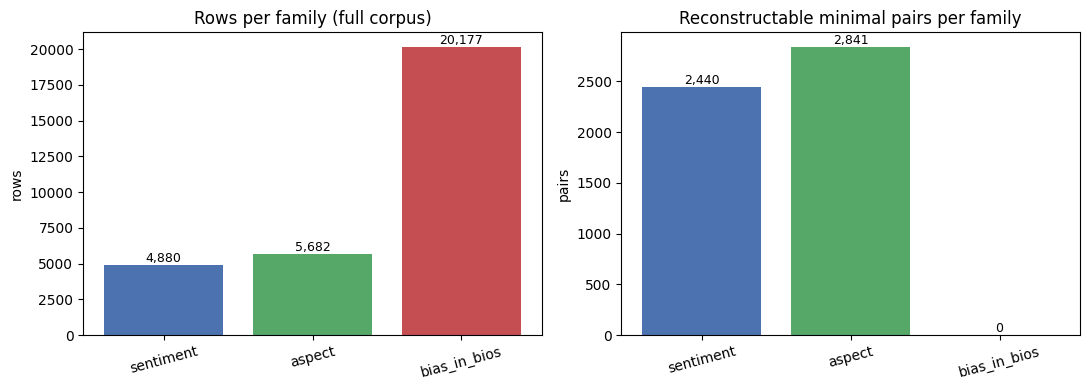


Reconstructed minimal pair  pair_id = sent_train_4
  token_overlap_with_partner = 0.6471
  [content_off / negative] Long, boring, blasphemous. Never have I been so glad to see ending credits roll.
  [content_on  / positive] Long, fascinating, soulful. Never have I been so sad to see ending credits roll.


In [11]:
# ---- (a) Per-family summary table (full corpus, from metadata) ----
fs = summary["family_summary"]
fams = list(fs.keys())
print(f"{'family':24s} {'role':13s} {'rows':>7s} {'pairs':>7s} {'license':>12s}")
print("-" * 70)
full_rows, full_pairs = [], []
for fam in fams:
    s = fs[fam]
    role = "boundary-null" if fam == "bias_in_bios_boundary" else "supporting"
    npairs = s.get("n_pairs") or s.get("n_pairs_total") or 0
    full_rows.append(s["n_rows"]); full_pairs.append(npairs)
    print(f"{fam:24s} {role:13s} {s['n_rows']:7d} {npairs:7d} {s['license']:>12s}")

# ---- (b) Bar charts: full-corpus rows and reconstructable pairs per family ----
short = [f.replace("_boundary", "").replace("restaurant_", "") for f in fams]
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(short, full_rows, color=["#4C72B0", "#55A868", "#C44E52"])
ax[0].set_title("Rows per family (full corpus)"); ax[0].set_ylabel("rows")
for i, v in enumerate(full_rows):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
ax[1].bar(short, full_pairs, color=["#4C72B0", "#55A868", "#C44E52"])
ax[1].set_title("Reconstructable minimal pairs per family"); ax[1].set_ylabel("pairs")
for i, v in enumerate(full_pairs):
    ax[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
for a in ax:
    a.tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

# ---- (c) Reconstruct one sentiment minimal pair from pair_id / partner_id ----
sent_pairs = {pid: mem for pid, mem in pairs.items()
              if mem[0]["metadata_family"] == "sentiment"}
pid, mem = sorted(sent_pairs.items())[0]
off = next(m for m in mem if m["metadata_pair_role"] == "content_off")  # negative
on  = next(m for m in mem if m["metadata_pair_role"] == "content_on")   # positive
print(f"\nReconstructed minimal pair  pair_id = {pid}")
print(f"  token_overlap_with_partner = {on['metadata_meta']['token_overlap_with_partner']}")
print(f"  [content_off / {off['output']}] {off['input']}")
print(f"  [content_on  / {on['output']}] {on['input']}")
